# Product Review Sentiment Analysis (Sentiment Analysis)

This notebook demonstrates a clean, minimal, and highly readable Machine Learning project for analyzing product reviews using Sentiment Analysis. We build an end-to-end NLP pipeline using standard Python libraries (`pandas`, `numpy`, `re`, `matplotlib`, `seaborn`, and `scikit-learn`).

### Pipeline Workflow:
1. **Dataset Generation**: Dynamically creating a realistic synthetic dataset (600 product reviews) to ensure out-of-the-box reproducibility.
2. **Text Preprocessing**: Normalizing text to lowercase, removing punctuation, and cleaning whitespace.
3. **Feature Engineering**: Vectorizing textual features using TF-IDF (Term Frequency-Inverse Document Frequency).
4. **Model Training**: Training a lightweight Logistic Regression model.
5. **Evaluation**: Generating a classification report, plotting a confusion matrix heatmap, and performing sample inference.

## 1. Setup & Library Imports

In [1]:
# Import core data handling and processing libraries
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Import modeling, vectorization, and evaluation components
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for guaranteed reproducibility
np.random.seed(42)
random.seed(42)
print("Libraries successfully imported and random seeds fixed to 42.")

Libraries successfully imported and random seeds fixed to 42.


## 2. Realistic Synthetic Dataset Generation

To prevent network failures or authentication issues, we dynamically generate a realistic dataset of 600 reviews with balanced sentiments (300 Positive and 300 Negative).

In [2]:
# Review generation template pools
pos_templates = [
    "This {product} is absolutely {adj}! {extra}.",
    "I highly recommend this {product}. It is very {adj} and works perfectly.",
    "Best purchase I have made in a long time. The {product} is {adj}.",
    "Extremely satisfied with the {product}. Fast shipping and {adj} quality.",
    "Very easy to use, highly {adj} and durable.",
    "Works great! The design is {adj} and it does exactly what is advertised.",
    "Fantastic value for money. Very {adj} and reliable.",
    "I love it! The {product} is surprisingly {adj}."
]

neg_templates = [
    "This {product} is completely {adj}. {extra}.",
    "Waste of money. The {product} is very {adj} and stopped working after a day.",
    "Worst purchase ever. Extremely {adj} quality and feels cheap.",
    "Very disappointed with the {product}. It arrived broken and is {adj}.",
    "Hard to use, not user-friendly, and feels very {adj}.",
    "Does not work as advertised. The quality is {adj} and customer service is slow.",
    "Horrible experience. The {product} is {adj} and useless.",
    "I regret buying this. The {product} is extremely {adj}."
]

products = ["headphones", "smartwatch", "keyboard", "phone charger", "vacuum cleaner", "coffee maker", "wireless mouse", "bluetooth speaker"]
pos_adjectives = ["excellent", "wonderful", "amazing", "high-quality", "reliable", "durable", "sturdy", "fantastic", "awesome"]
neg_adjectives = ["terrible", "cheap", "flimsy", "useless", "broken", "defective", "disappointing", "horrible", "faulty"]
pos_extras = ["Great customer service", "Exceeded my expectations", "A must-have for everyone", "Will definitely buy again"]
neg_extras = ["Do not buy", "Very frustrated", "Returning it immediately", "Worst experience ever"]

reviews = []
labels = []

# Generate 300 positive reviews
for _ in range(300):
    template = random.choice(pos_templates)
    review = template.format(
        product=random.choice(products),
        adj=random.choice(pos_adjectives),
        extra=random.choice(pos_extras)
    )
    reviews.append(review)
    labels.append("Positive")

# Generate 300 negative reviews
for _ in range(300):
    template = random.choice(neg_templates)
    review = template.format(
        product=random.choice(products),
        adj=random.choice(neg_adjectives),
        extra=random.choice(neg_extras)
    )
    reviews.append(review)
    labels.append("Negative")

# Construct DataFrame
df = pd.DataFrame({
    'Review_Text': reviews,
    'Sentiment_Label': labels
})

# Shuffle dataset using the fixed seed for reproducibility
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Generated Dataset Shape: {df.shape}")
print("Class Distribution:")
print(df['Sentiment_Label'].value_counts())
df.head()

Generated Dataset Shape: (600, 2)
Class Distribution:
Sentiment_Label
Positive    300
Negative    300
Name: count, dtype: int64


,Review_Text,Sentiment_Label
0,Extremely satisfied with the keyboard. Fast sh...,Positive
1,Does not work as advertised. The quality is fl...,Negative
2,Waste of money. The vacuum cleaner is very fli...,Negative
3,Best purchase I have made in a long time. The ...,Positive
4,Fantastic value for money. Very awesome and re...,Positive


## 3. Text Preprocessing & Cleaning

First, we remove any missing values and duplicate rows. Then, we apply a minimal text cleaning helper function that converts tokens to lowercase, strips punctuation, and normalizes spacing using simple regex.

In [3]:
# Drop any duplicate rows or nulls
df = df.dropna().drop_duplicates().reset_index(drop=True)

def preprocess_text(text):
    """
    Cleans raw review text:
    - Lowercases text
    - Removes punctuation and special symbols using regex
    - Strips leading/trailing spaces and collapses multiple spaces
    """
    if not isinstance(text, str):
        return ""
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation using regex, leaving only letters, numbers, and whitespace
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Clean the review texts
df['Cleaned_Review'] = df['Review_Text'].apply(preprocess_text)

# Show raw and cleaned text side-by-side
df[['Review_Text', 'Cleaned_Review']].head()

,Review_Text,Cleaned_Review
0,Extremely satisfied with the keyboard. Fast sh...,extremely satisfied with the keyboard fast shi...
1,Does not work as advertised. The quality is fl...,does not work as advertised the quality is fli...
2,Waste of money. The vacuum cleaner is very fli...,waste of money the vacuum cleaner is very flim...
3,Best purchase I have made in a long time. The ...,best purchase i have made in a long time the v...
4,Fantastic value for money. Very awesome and re...,fantastic value for money very awesome and rel...


## 4. Train-Test Split & TF-IDF Vectorization

We partition the dataset into 80% training data and 20% test data. We use a stratified split to ensure equal representation of classes. Then, we apply `TfidfVectorizer` to convert text into numeric matrices.

In [4]:
# Stratified train-test split (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    df['Cleaned_Review'],
    df['Sentiment_Label'],
    test_size=0.2,
    random_state=42,
    stratify=df['Sentiment_Label']
)

# Extract TF-IDF features with standard English stop words and a restricted feature count of 1000
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')

# Fit on train set, transform train and test sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training set shape: {X_train_tfidf.shape}")
print(f"Test set shape: {X_test_tfidf.shape}")

Training set shape: (281, 82)
Test set shape: (71, 82)


## 5. Model Training

In [5]:
# Train a Logistic Regression model as a lightweight baseline
model = LogisticRegression(random_state=42)
model.fit(X_train_tfidf, y_train)

print("Logistic Regression model successfully trained.")

Logistic Regression model successfully trained.


## 6. Model Evaluation

We generate the model predictions on the test set and output standard classification metrics (precision, recall, f1-score, accuracy). We also render a Confusion Matrix heatmap.

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        36
    Positive       1.00      1.00      1.00        35

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71



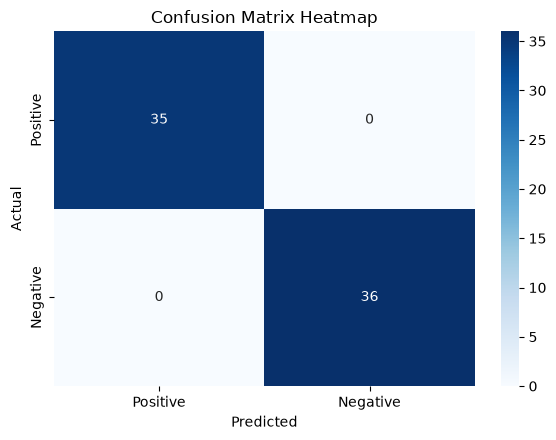

In [6]:
# Perform predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Compute and plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["Positive", "Negative"])
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Positive", "Negative"], 
            yticklabels=["Positive", "Negative"])
plt.title("Confusion Matrix Heatmap")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 7. Sample Predictions Visualization

Let's extract 5 random test samples and visualize their actual vs. predicted sentiments side-by-side.

In [7]:
# Select 5 random indices from the test split
test_indices = y_test.index
random_indices = np.random.choice(test_indices, size=5, replace=False)

# Extract columns for sample verification
samples_df = pd.DataFrame({
    'Original_Review': df.loc[random_indices, 'Review_Text'].values,
    'Cleaned_Review': df.loc[random_indices, 'Cleaned_Review'].values,
    'Actual_Sentiment': df.loc[random_indices, 'Sentiment_Label'].values,
    'Predicted_Sentiment': model.predict(tfidf.transform(df.loc[random_indices, 'Cleaned_Review'])).tolist()
})

samples_df

,Original_Review,Cleaned_Review,Actual_Sentiment,Predicted_Sentiment
0,Waste of money. The phone charger is very faul...,waste of money the phone charger is very fault...,Negative,Negative
1,I love it! The coffee maker is surprisingly re...,i love it the coffee maker is surprisingly rel...,Positive,Positive
2,This phone charger is completely cheap. Do not...,this phone charger is completely cheap do not buy,Negative,Negative
3,Extremely satisfied with the smartwatch. Fast ...,extremely satisfied with the smartwatch fast s...,Positive,Positive
4,This wireless mouse is absolutely excellent! G...,this wireless mouse is absolutely excellent gr...,Positive,Positive
